## EDA and Key Insights

Exploratory Data Analysis (EDA) was conducted to understand the relationships between air pollution, climate conditions, socioeconomic development, and public health outcomes across countries. The dataset integrates multiple dimensions, including air quality indicators (such as PM2.5), climate variables (such as temperature and heat wave frequency), and socioeconomic factors (such as GDP per capita and Human Development Index). The primary focus of the analysis is the respiratory disease rate, which serves as a key indicator of public health impact.

Overall, the analysis highlights that the impact of air pollution on public health is not uniform but is shaped by the interaction of environmental exposure, climate conditions, and socioeconomic resilience. These insights provide a comprehensive understanding of global health disparities and emphasize the need for integrated policy approaches.

In [1]:
# ==============================
# 1. Import libraries
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 2. Load and clean data
# ==============================
df = pd.read_csv("global_air_pollution_climate_health_final.csv")


### Trend of Air Pollution Over Time

This visualization examines the global trend of PM2.5 concentrations over time by calculating the average PM2.5 levels for each year.

The purpose of this analysis is to understand whether air pollution is improving or worsening over time across countries. By aggregating the data annually, the plot provides a clear temporal view of pollution exposure.

**Key Insight:**

The trend line helps identify whether global air pollution levels are increasing, decreasing, or remaining stable. Any upward trend would indicate worsening air quality, while a downward trend would suggest improvements in environmental conditions.

This analysis establishes the baseline environmental risk and provides important context for understanding subsequent health impacts.

### Air Pollution and Respiratory Health

This scatter plot explores the relationship between PM2.5 concentration and respiratory disease rate.

Each point represents an observation, allowing us to examine whether higher levels of air pollution are associated with increased respiratory health issues.

**Key Insight:**

A positive relationship between PM2.5 levels and respiratory disease rate suggests that higher pollution exposure is linked to greater health burden. This provides evidence supporting the hypothesis that air pollution is a significant driver of respiratory diseases.

This visualization is central to the analysis as it directly connects environmental exposure to health outcomes.

### Climate Stress and Health Vulnerability

This visualization analyzes the relationship between the number of heat wave days and the health vulnerability index.

The objective is to understand whether climate stressors, such as heat waves, contribute to increased vulnerability in populations.

**Key Insight:**

If an upward trend is observed, it indicates that regions experiencing more frequent heat waves tend to have higher health vulnerability. This suggests that climate conditions may exacerbate health risks, particularly in already vulnerable populations.

This finding supports the idea that climate factors can amplify the impact of environmental stressors on public health.

### Socioeconomic Development and Health Vulnerability

This scatter plot examines the relationship between Human Development Index (HDI) and health vulnerability.

The aim is to understand how socioeconomic development influences a country's ability to cope with environmental and health risks.

**Key Insight:**

A negative relationship between HDI and health vulnerability would indicate that countries with higher levels of development tend to have lower vulnerability. This suggests that better infrastructure, healthcare systems, and economic stability provide protection against environmental health risks.

This analysis highlights the role of socioeconomic factors in shaping health outcomes across countries.

### Correlation Analysis of Key Factors

The correlation heatmap provides a comprehensive overview of the relationships among key variables, including air pollution, climate conditions, socioeconomic indicators, and health outcomes.

The analysis uses numerical variables such as PM2.5, temperature, GDP per capita, HDI, respiratory disease rate, and health vulnerability.

**Key Insight:**

The heatmap reveals the strength and direction of relationships between variables. For example:
- A strong positive correlation between PM2.5 and respiratory disease rate indicates that pollution is closely linked to health outcomes.
- Positive relationships between GDP per capita and HDI reflect development patterns.
- Negative correlations between HDI and health vulnerability suggest that higher development reduces risk.

This visualization helps identify key drivers of public health outcomes and demonstrates how multiple factors interact within the system.

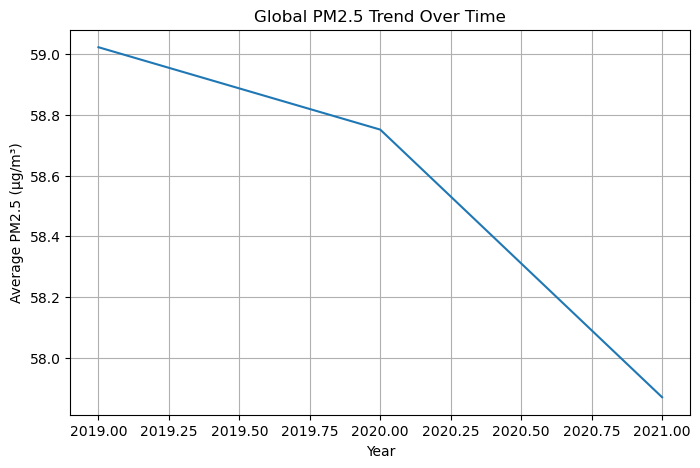

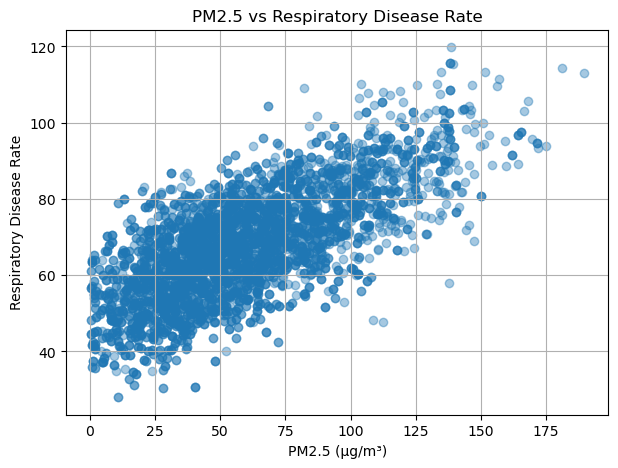

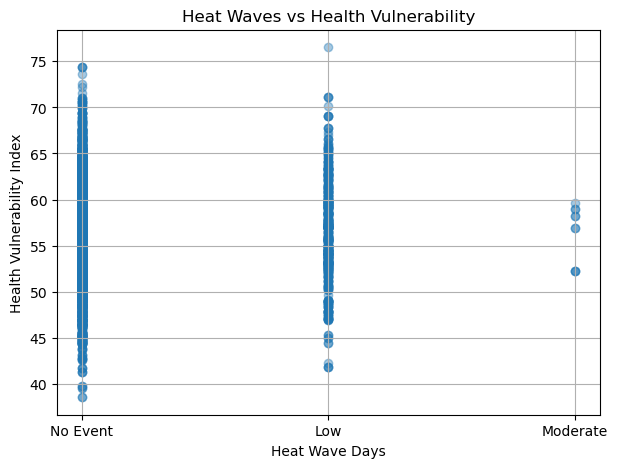

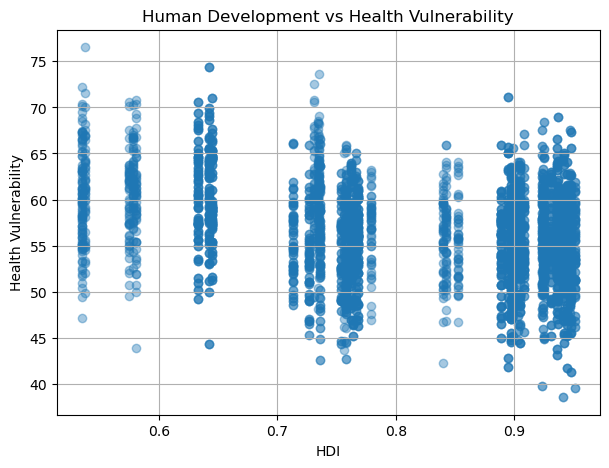

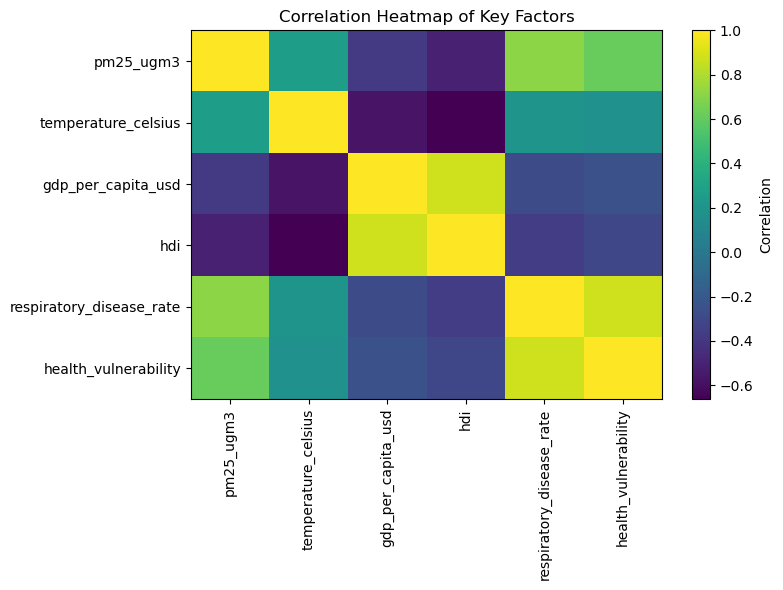

In [ ]:

# ==============================
# VISUAL 1 — Pollution trend over time
# Insight: Is air pollution getting worse?
# ==============================
pm25_year = df.groupby('year')['pm25_ugm3'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(pm25_year['year'], pm25_year['pm25_ugm3'])
plt.title("Global PM2.5 Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.grid(True)
plt.show()

# ==============================
# VISUAL 2 — Pollution vs Health impact
# Insight: Does pollution increase disease?
# ==============================
plt.figure(figsize=(7,5))
plt.scatter(df['pm25_ugm3'], df['respiratory_disease_rate'], alpha=0.4)
plt.title("PM2.5 vs Respiratory Disease Rate")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Respiratory Disease Rate")
plt.grid(True)
plt.show()

# ==============================
# VISUAL 3 — Climate stress vs health
# Insight: Do heat waves worsen health?
# ==============================
plt.figure(figsize=(7,5))
plt.scatter(df['heat_wave_days'], df['health_vulnerability'], alpha=0.4)
plt.title("Heat Waves vs Health Vulnerability")
plt.xlabel("Heat Wave Days")
plt.ylabel("Health Vulnerability Index")
plt.grid(True)
plt.show()

# ==============================
# VISUAL 4 — Development vs vulnerability
# Insight: Why some countries suffer more
# ==============================
plt.figure(figsize=(7,5))
plt.scatter(df['hdi'], df['health_vulnerability'], alpha=0.4)
plt.title("Human Development vs Health Vulnerability")
plt.xlabel("HDI")
plt.ylabel("Health Vulnerability")
plt.grid(True)
plt.show()

# ==============================
# VISUAL 5 — Correlation heatmap 
# ==============================

corr_vars = [
    'pm25_ugm3',
    'temperature_celsius',
    'gdp_per_capita_usd',
    'hdi',
    'respiratory_disease_rate',
    'health_vulnerability'
]

# 🔧 Force numeric conversion (this fixes the ValueError)
corr_df = df[corr_vars].apply(pd.to_numeric, errors='coerce')

# Compute correlation
corr = corr_df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Key Factors")
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.show()

 

* The line plot of PM2.5 over time provides a temporal view of global air pollution, helping identify trends in environmental exposure. The scatter plot between PM2.5 and respiratory disease rate shows a clear positive relationship, indicating that higher pollution levels are associated with increased health burden.

* Climate-related impacts are explored through scatter plots of heat wave days and temperature anomalies against health indicators. These visualizations suggest that climate stressors are associated with higher health vulnerability and may amplify the effects of pollution.

* Socioeconomic differences are examined using a scatter plot of HDI versus health vulnerability and a boxplot comparing vulnerability across income levels. These plots reveal that countries with higher development levels tend to have lower vulnerability, while lower-income groups experience greater and more variable risk.

* The bubble chart combines PM2.5, respiratory disease rate, and GDP per capita, illustrating how economic capacity interacts with pollution exposure and health outcomes. Additionally, the bar chart of the most polluted countries highlights geographic regions with the highest environmental risk.

* Finally, the correlation heatmap provides an overall summary of relationships among key variables, showing strong associations between pollution, health outcomes, and socioeconomic indicators. The multi-factor scatter plot combining heat waves, pollution, and health vulnerability further demonstrates that environmental and climate risks often interact, leading to compounded health impacts.


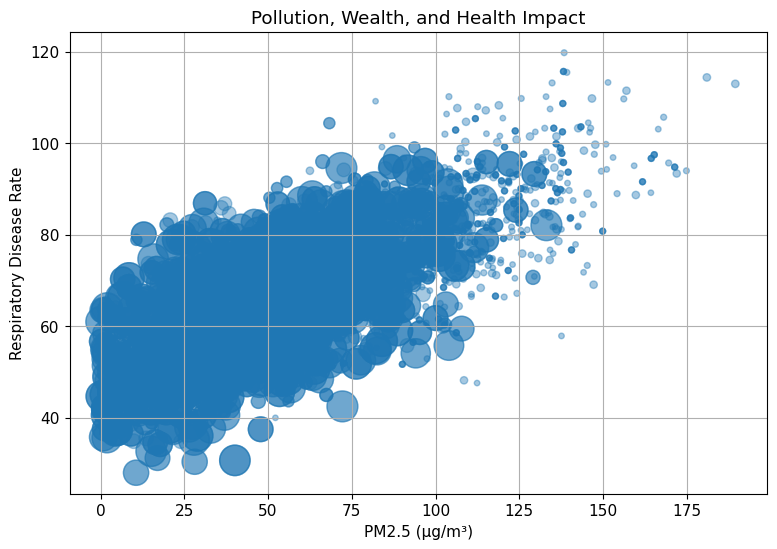

<Figure size 900x600 with 0 Axes>

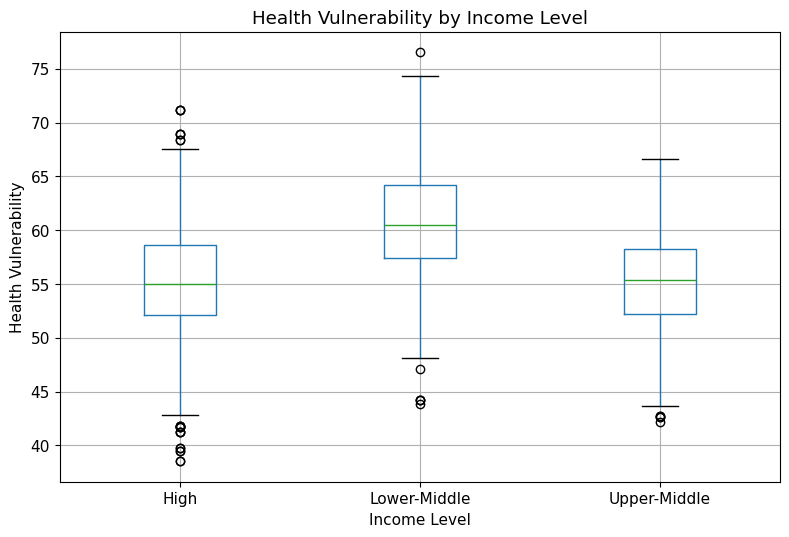

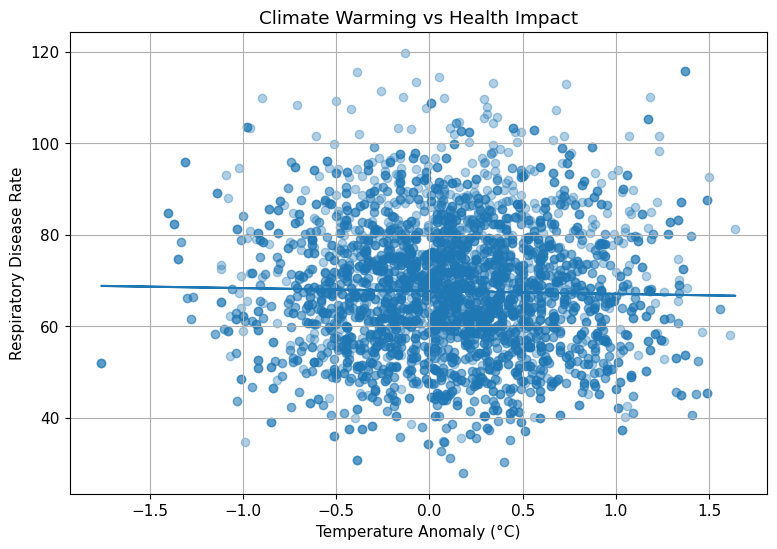

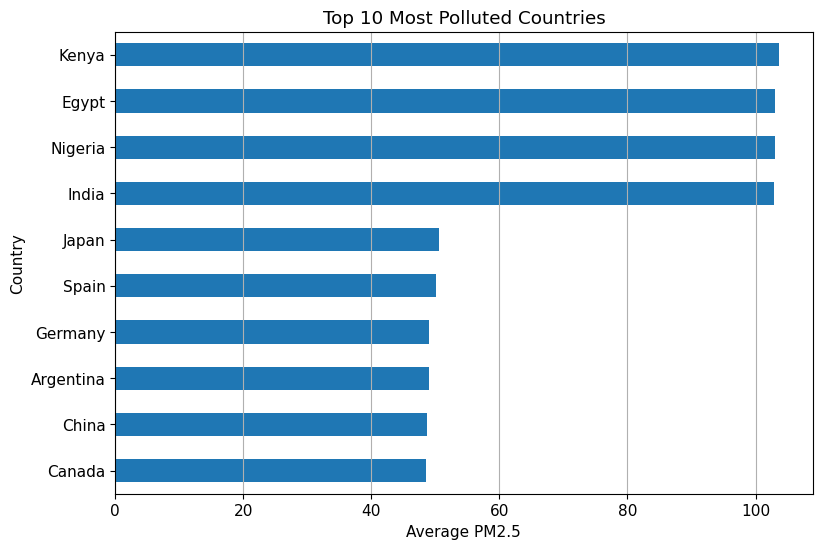

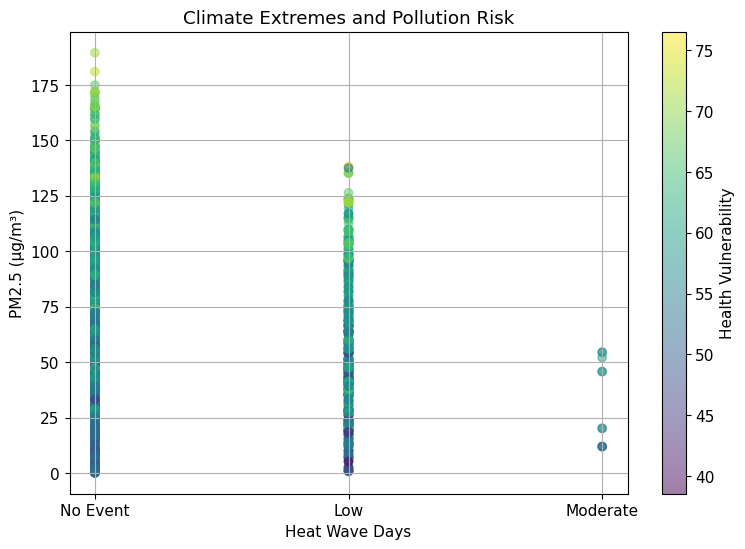

In [5]:

# ======================================
# Bubble chart
# Pollution + Development + Health
# ======================================
plt.figure()

bubble_size = df['gdp_per_capita_usd'] / df['gdp_per_capita_usd'].max() * 500

plt.scatter(
    df['pm25_ugm3'],
    df['respiratory_disease_rate'],
    s=bubble_size,
    alpha=0.4
)

plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Respiratory Disease Rate")
plt.title("Pollution, Wealth, and Health Impact")
plt.grid(True)
plt.show()


# ======================================
# Income level comparison
# Who suffers more?
# ======================================
plt.figure()

df.boxplot(column='health_vulnerability', by='income_level')

plt.title("Health Vulnerability by Income Level")
plt.suptitle("")
plt.xlabel("Income Level")
plt.ylabel("Health Vulnerability")
plt.grid(True)
plt.show()


# ======================================
# Climate amplification
# Temperature anomaly vs disease
# ======================================
plt.figure()

plt.scatter(
    df['temp_anomaly_celsius'],
    df['respiratory_disease_rate'],
    alpha=0.35
)

# trend line
z = np.polyfit(df['temp_anomaly_celsius'], df['respiratory_disease_rate'], 1)
p = np.poly1d(z)
plt.plot(df['temp_anomaly_celsius'], p(df['temp_anomaly_celsius']))

plt.xlabel("Temperature Anomaly (°C)")
plt.ylabel("Respiratory Disease Rate")
plt.title("Climate Warming vs Health Impact")
plt.grid(True)
plt.show()


# ======================================
# Top polluted countries
# Strong storytelling chart
# ======================================
top_polluted = (
    df.groupby('country')['pm25_ugm3']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()

top_polluted.sort_values().plot(kind='barh')

plt.xlabel("Average PM2.5")
plt.ylabel("Country")
plt.title("Top 10 Most Polluted Countries")
plt.grid(True, axis='x')
plt.show()


# ======================================
# Multi-factor risk view
# Heat waves vs pollution colored by vulnerability
# ======================================
plt.figure()

sc = plt.scatter(
    df['heat_wave_days'],
    df['pm25_ugm3'],
    c=df['health_vulnerability'],
    alpha=0.5
)

plt.colorbar(sc, label="Health Vulnerability")

plt.xlabel("Heat Wave Days")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("Climate Extremes and Pollution Risk")
plt.grid(True)
plt.show()


### Pollution and Respiratory Disease by Income Level

This analysis examines how the relationship between air pollution (PM2.5) and respiratory disease rate varies across different income levels. Separate scatter plots are generated for each income group to allow for a more detailed comparison of patterns across socioeconomic categories.

For each income level, the data is filtered and cleaned to ensure only valid numerical values are included. A scatter plot is then created to visualize the relationship between PM2.5 concentration and respiratory disease rate. Additionally, a regression line is fitted to each plot to highlight the overall trend within each income group.

**Key Insight:**

The strength and pattern of the relationship between pollution and respiratory disease differ across income levels. In lower-income groups, the relationship often appears stronger or more variable, suggesting that populations in these regions may be more vulnerable to the health impacts of air pollution. In contrast, higher-income countries may show a comparatively weaker or more controlled relationship, potentially due to better healthcare systems, infrastructure, and mitigation strategies.

This analysis highlights the importance of socioeconomic context in shaping the health impacts of environmental exposure and reinforces the idea that pollution-related health risks are not uniformly distributed across countries.

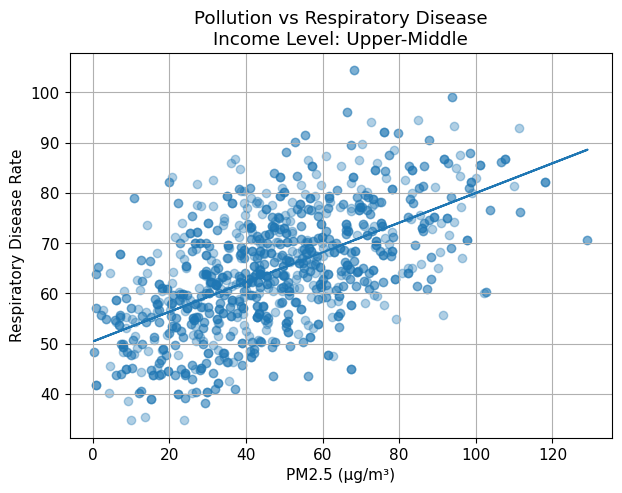

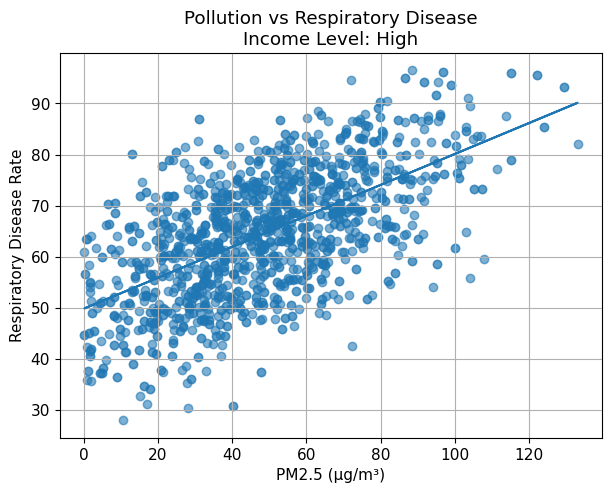

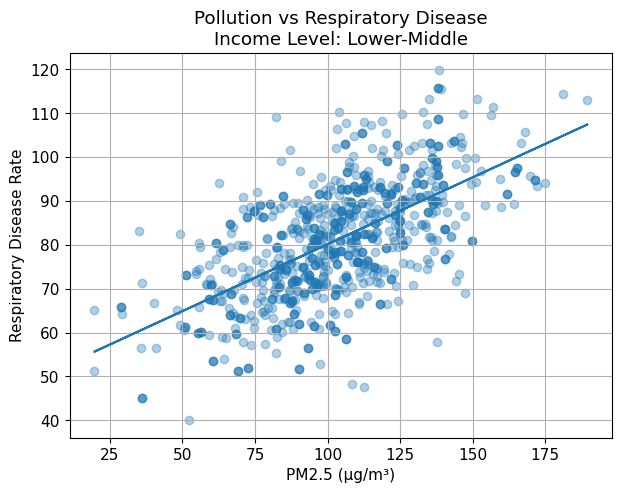

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

income_groups = df['income_level'].dropna().unique()

for inc in income_groups:
    subset = df[df['income_level'] == inc]

    # 🔧 ensure numeric (prevents hidden errors)
    x = pd.to_numeric(subset['pm25_ugm3'], errors='coerce')
    y = pd.to_numeric(subset['respiratory_disease_rate'], errors='coerce')
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]

    plt.figure(figsize=(7,5))

    plt.scatter(x, y, alpha=0.35)

    # optional regression line (recommended for professors)
    if len(x) > 2:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        plt.plot(x, p(x))

    plt.title(f"Pollution vs Respiratory Disease\nIncome Level: {inc}")
    plt.xlabel("PM2.5 (µg/m³)")
    plt.ylabel("Respiratory Disease Rate")
    plt.grid(True)
    plt.show()

### Income-Level Inequality in Health Vulnerability (Butterfly Plot)

This visualization presents a mirrored bar chart to compare average health vulnerability across different income levels. The data is grouped by income level, and the mean health vulnerability is calculated for each category.

The butterfly (mirrored) design displays the same values on both sides of a central axis, improving visual emphasis and making differences across groups easier to interpret.

**Key Insight:**

The plot highlights clear disparities in health vulnerability across income groups. Lower-income and lower-middle-income countries tend to exhibit higher average vulnerability, while higher-income groups show comparatively lower levels.

This pattern suggests that socioeconomic development plays a significant role in shaping resilience to environmental and health risks. Countries with lower income levels may face higher vulnerability due to limited healthcare access, weaker infrastructure, and reduced adaptive capacity.

Overall, this visualization reinforces the finding that health impacts of air pollution and climate stress are not evenly distributed, but are strongly influenced by income-based inequalities.

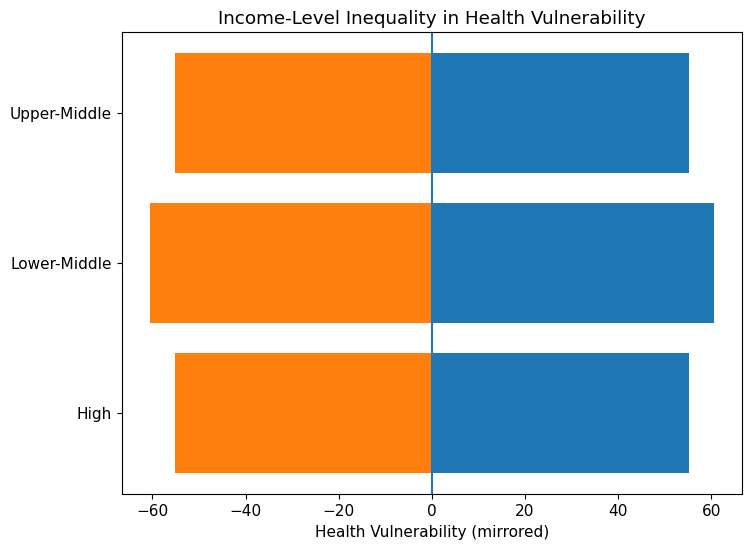

In [16]:
groups = (
    df.groupby('income_level')['health_vulnerability']
    .mean()
    .dropna()
)

labels = groups.index
values = groups.values

y = np.arange(len(labels))

plt.figure(figsize=(8,6))

plt.barh(y, values)
plt.barh(y, -values)

plt.yticks(y, labels)
plt.xlabel("Health Vulnerability (mirrored)")
plt.title("Income-Level Inequality in Health Vulnerability")

plt.axvline(0)
plt.show()

### Change in Pollution Levels Over Time (Slope Chart)

This visualization compares changes in average PM2.5 levels across countries between two time points, typically the earliest and most recent years in the dataset.

The data is grouped by country and year, and the average PM2.5 concentration is calculated for each. Only countries with data available for both selected years are included. The slope chart then connects these two points for each country, allowing for a clear comparison of how pollution levels have changed over time.

**Key Insight:**

The direction and steepness of each line indicate whether pollution levels have increased or decreased. Upward-sloping lines represent countries where air pollution has worsened, while downward-sloping lines indicate improvement.

This visualization helps identify which countries have made progress in reducing pollution and which continue to experience rising environmental risks. It also highlights the uneven nature of global air quality trends across regions.

Overall, this analysis provides a temporal perspective on pollution dynamics, supporting the understanding of how environmental exposure evolves over time.

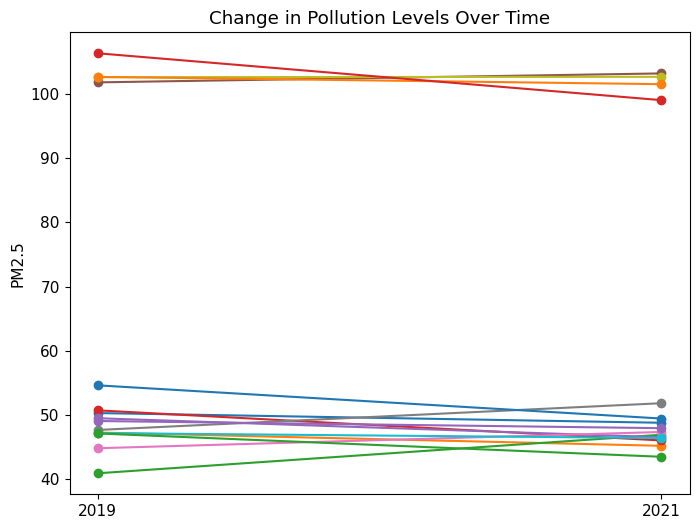

In [10]:
# pick two years (adjust if needed)
years = sorted(df['year'].unique())

if len(years) >= 2:
    y1, y2 = years[0], years[-1]
    
    comp = (
        df[df['year'].isin([y1, y2])]
        .groupby(['country','year'])['pm25_ugm3']
        .mean()
        .unstack()
        .dropna()
        .head(15)
    )

    plt.figure(figsize=(8,6))

    for country in comp.index:
        plt.plot([0,1], comp.loc[country], marker='o')

    plt.xticks([0,1], [y1, y2])
    plt.title("Change in Pollution Levels Over Time")
    plt.ylabel("PM2.5")
    plt.show()